# Comparing Two Treebanks of Aristotle's *Poetics*

This notebook compares two CoNLL-U dependency treebanks of Aristotle's *Poetics*:

| | **Bekker edition** | **Kassel edition** |
|---|---|---|
| **File** | `aristotle_poetics_tb.conllu` | `aristotle_poetics_kassel_tb.conllu` |
| **Source text** | Bekker, *Aristotelis Opera* (1831) | Kassel, *De arte poetica liber* (1965) |
| **Treebank origin** | Glaux 1.0 (auto-generated), corrected | Updated from the Bekker treebank |

We ask two questions:
1. **How do the two editions differ?** — Overview statistics, structural comparison.
2. **How and how often do the treebanks diverge because of different textual readings?** — Token-level alignment and classification of variants.

## 0. Setup & Parsing

In [4]:
import re
import unicodedata
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)

# ── CoNLL-U parser ──────────────────────────────────────────────────

def parse_conllu(path):
    """Parse a CoNLL-U file into a list of sentences.
    Each sentence is a dict with 'meta' (comment key-values) and
    'tokens' (list of 10-field tab-split rows, skipping MWTs)."""
    sentences = []
    cur = {'meta': {}, 'tokens': []}
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line:
                if cur['tokens']:
                    sentences.append(cur)
                cur = {'meta': {}, 'tokens': []}
            elif line.startswith('#'):
                m = re.match(r'^#\s*([\w.]+)\s*=\s*(.*)', line)
                if m:
                    cur['meta'][m.group(1)] = m.group(2).strip()
            else:
                fields = line.split('\t')
                if len(fields) >= 10:
                    tok_id = fields[0]
                    # skip multi-word tokens (e.g. 1-2) and empty nodes (e.g. 1.1)
                    if '-' not in tok_id and '.' not in tok_id:
                        cur['tokens'].append(fields)
    if cur['tokens']:
        sentences.append(cur)
    return sentences

# ── Utility helpers ─────────────────────────────────────────────────

def get_ref(misc):
    """Extract the Ref=... value from the MISC column."""
    m = re.search(r'Ref=([^|]+)', misc)
    return m.group(1) if m else None

def get_chapter_section(misc):
    """Extract chapter.section (first two levels) from the Ref field."""
    m = re.search(r'Ref=(\d+\.\d+)', misc)
    return m.group(1) if m else None

def get_chapter(misc):
    """Extract chapter number from the Ref field."""
    m = re.search(r'Ref=(\d+)', misc)
    return int(m.group(1)) if m else None

def strip_accents(s):
    """Remove combining diacritical marks (accents, breathings)."""
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

# ── Load ────────────────────────────────────────────────────────────


bekker_sents  = parse_conllu(BEKKER_PATH)
kassel_sents  = parse_conllu(KASSEL_PATH)

print(f'Bekker : {len(bekker_sents):>4} sentences, '
      f'{sum(len(s["tokens"]) for s in bekker_sents):>6} tokens')
print(f'Kassel : {len(kassel_sents):>4} sentences, '
      f'{sum(len(s["tokens"]) for s in kassel_sents):>6} tokens')

Bekker :  607 sentences,  11907 tokens
Kassel :  390 sentences,  11706 tokens


---
## 1. How Do the Two Editions Differ?

### 1.1 Basic corpus statistics

In [5]:
def corpus_stats(sents, label):
    """Compute summary statistics for one treebank."""
    n_tokens = sum(len(s['tokens']) for s in sents)
    n_words  = sum(1 for s in sents for t in s['tokens'] if t[3] != 'PUNCT')
    n_punct  = n_tokens - n_words
    chapters = set()
    sections = set()
    for s in sents:
        for t in s['tokens']:
            ch = get_chapter(t[9])
            cs = get_chapter_section(t[9])
            if ch: chapters.add(ch)
            if cs: sections.add(cs)
    lemmas = set(t[2] for s in sents for t in s['tokens'] if t[3] != 'PUNCT')
    return {
        'Edition': label,
        'Sentences': len(sents),
        'Tokens (total)': n_tokens,
        'Word tokens': n_words,
        'Punctuation tokens': n_punct,
        'Chapters': len(chapters),
        'Sections (ch.sec)': len(sections),
        'Unique lemmas': len(lemmas),
    }

stats = pd.DataFrame([
    corpus_stats(bekker_sents,  'Bekker (1831)'),
    corpus_stats(kassel_sents, 'Kassel (1965)'),
]).set_index('Edition')

stats.T

Edition,Bekker (1831),Kassel (1965)
Sentences,607,390
Tokens (total),11907,11706
Word tokens,10401,10364
Punctuation tokens,1506,1342
Chapters,26,26
Sections (ch.sec),330,355
Unique lemmas,1290,1428


### 1.2 Sentence segmentation

The two treebanks segment the same text into **very different numbers of sentences**. This reflects different editorial punctuation choices.

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


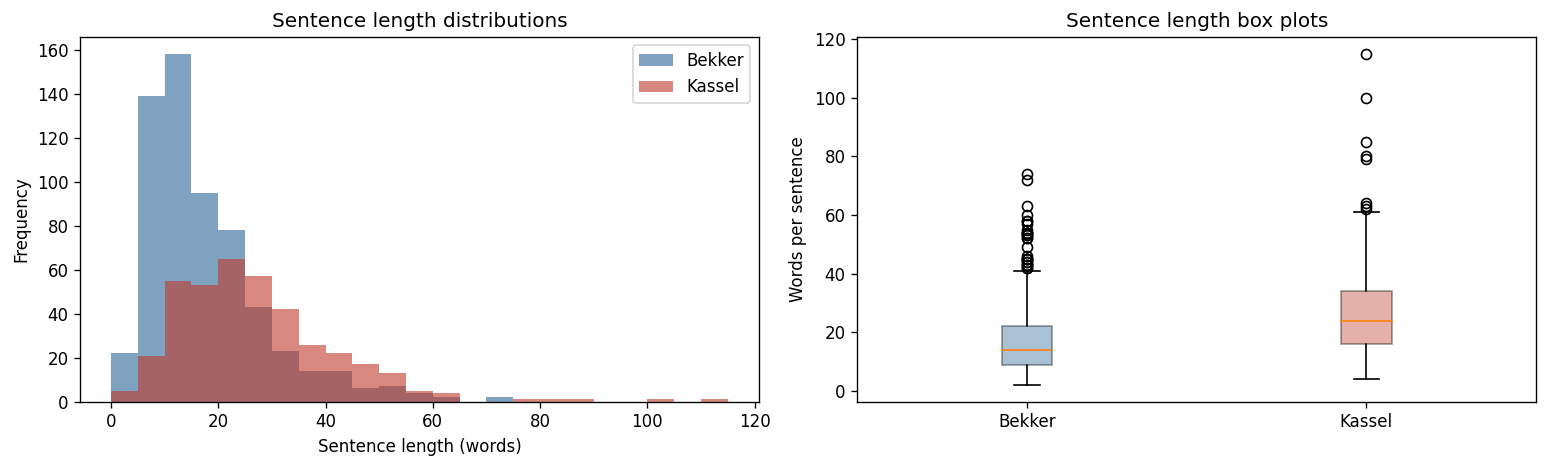

Bekker  — median:  14 words, mean: 17.1, max: 74
Kassel  — median:  24 words, mean: 26.6, max: 115


In [6]:
def sent_lengths(sents):
    return [len([t for t in s['tokens'] if t[3] != 'PUNCT']) for s in sents]

bk_lens = sent_lengths(bekker_sents)
ks_lens = sent_lengths(kassel_sents)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bk_lens, bins=range(0, max(bk_lens)+5, 5), alpha=0.6, label='Bekker', color='#2a6496')
axes[0].hist(ks_lens, bins=range(0, max(ks_lens)+5, 5), alpha=0.6, label='Kassel', color='#c0392b')
axes[0].set_xlabel('Sentence length (words)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sentence length distributions')
axes[0].legend()

data_box = pd.DataFrame({
    'Bekker': pd.Series(bk_lens),
    'Kassel': pd.Series(ks_lens),
})
bp = axes[1].boxplot([bk_lens, ks_lens], patch_artist=True)
axes[1].set_xticklabels(['Bekker', 'Kassel'])
bp['boxes'][0].set(facecolor='#2a6496', alpha=0.4)
bp['boxes'][1].set(facecolor='#c0392b', alpha=0.4)
axes[1].set_ylabel('Words per sentence')
axes[1].set_title('Sentence length box plots')

plt.tight_layout()
plt.show()

print(f'Bekker  — median: {sorted(bk_lens)[len(bk_lens)//2]:>3} words, '
      f'mean: {sum(bk_lens)/len(bk_lens):.1f}, max: {max(bk_lens)}')
print(f'Kassel  — median: {sorted(ks_lens)[len(ks_lens)//2]:>3} words, '
      f'mean: {sum(ks_lens)/len(ks_lens):.1f}, max: {max(ks_lens)}')

### 1.3 POS-tag distribution

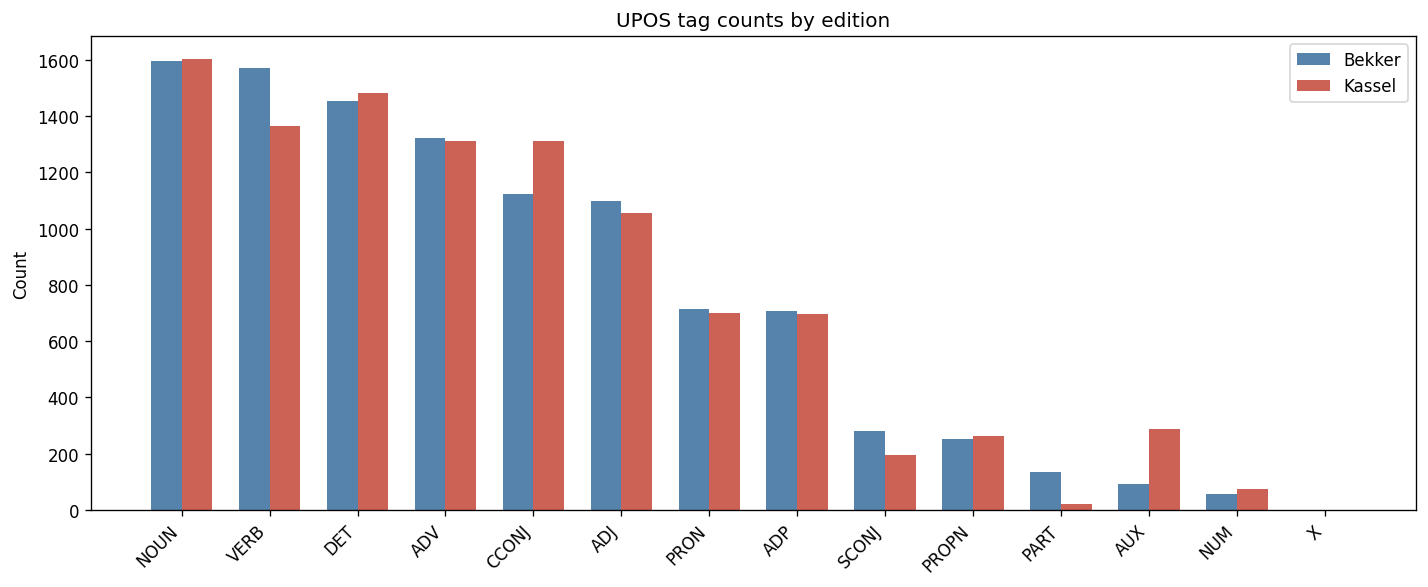

,Bekker,Kassel,Diff (K−B)
NOUN,1596,1604,8
VERB,1570,1363,-207
DET,1454,1481,27
ADV,1321,1310,-11
CCONJ,1122,1311,189
ADJ,1097,1054,-43
PRON,714,700,-14
ADP,707,698,-9
SCONJ,282,197,-85
PROPN,253,262,9


In [7]:
def pos_counts(sents):
    return Counter(t[3] for s in sents for t in s['tokens'] if t[3] != 'PUNCT')

bk_pos = pos_counts(bekker_sents)
ks_pos = pos_counts(kassel_sents)

all_pos = sorted(set(bk_pos) | set(ks_pos))
pos_df = pd.DataFrame({
    'Bekker': [bk_pos.get(p, 0) for p in all_pos],
    'Kassel': [ks_pos.get(p, 0) for p in all_pos],
}, index=all_pos)

pos_df['Diff (K−B)'] = pos_df['Kassel'] - pos_df['Bekker']
pos_df = pos_df.sort_values('Bekker', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(pos_df))
w = 0.35
ax.bar([i - w/2 for i in x], pos_df['Bekker'], w, label='Bekker', color='#2a6496', alpha=0.8)
ax.bar([i + w/2 for i in x], pos_df['Kassel'], w, label='Kassel', color='#c0392b', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(pos_df.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('UPOS tag counts by edition')
ax.legend()
plt.tight_layout()
plt.show()

pos_df

### 1.4 Dependency relation distribution

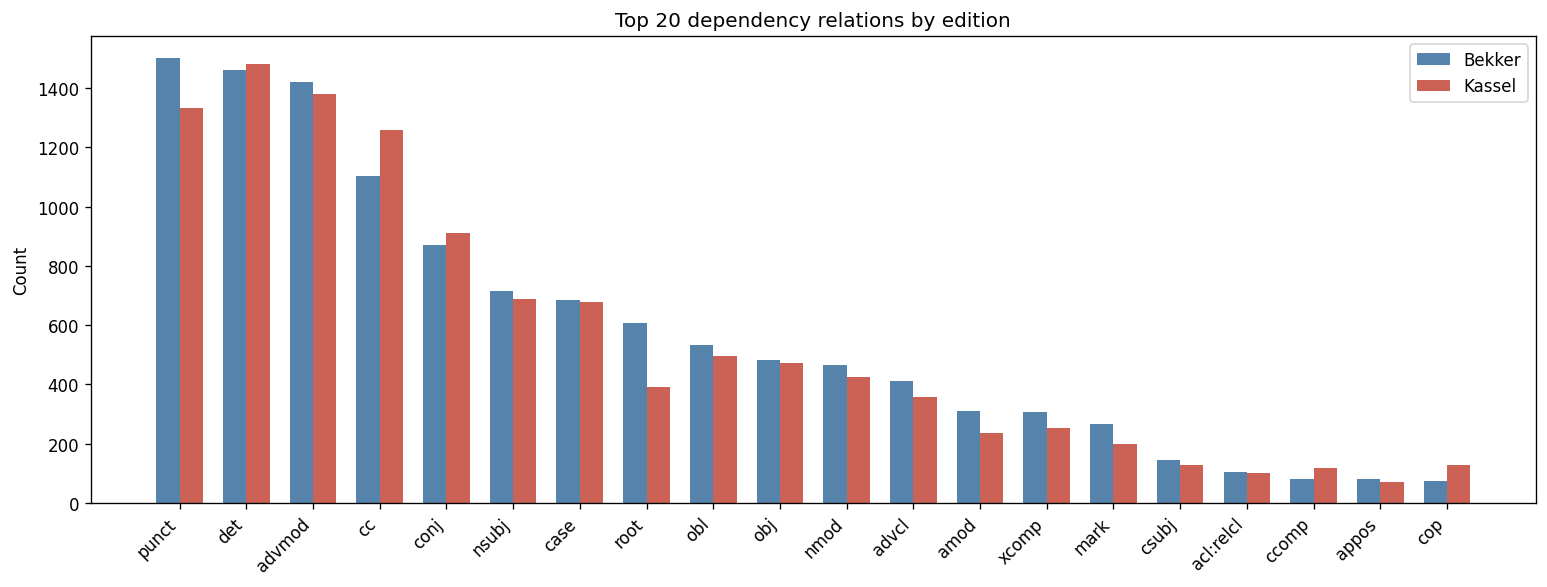

,Bekker,Kassel,Diff (K−B)
punct,1501,1333,-168
det,1461,1483,22
advmod,1422,1381,-41
cc,1105,1258,153
conj,871,912,41
nsubj,716,690,-26
case,685,678,-7
root,609,391,-218
obl,532,496,-36
obj,482,473,-9


In [8]:
def deprel_counts(sents):
    return Counter(t[7] for s in sents for t in s['tokens'])

bk_dep = deprel_counts(bekker_sents)
ks_dep = deprel_counts(kassel_sents)

all_dep = sorted(set(bk_dep) | set(ks_dep))
dep_df = pd.DataFrame({
    'Bekker': [bk_dep.get(d, 0) for d in all_dep],
    'Kassel': [ks_dep.get(d, 0) for d in all_dep],
}, index=all_dep)
dep_df['Diff (K−B)'] = dep_df['Kassel'] - dep_df['Bekker']
dep_df = dep_df.sort_values('Bekker', ascending=False)

# Show top 20 deprels
top = dep_df.head(20)
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(top))
w = 0.35
ax.bar([i - w/2 for i in x], top['Bekker'], w, label='Bekker', color='#2a6496', alpha=0.8)
ax.bar([i + w/2 for i in x], top['Kassel'], w, label='Kassel', color='#c0392b', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(top.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Top 20 dependency relations by edition')
ax.legend()
plt.tight_layout()
plt.show()

dep_df

### 1.5 Tokens per chapter

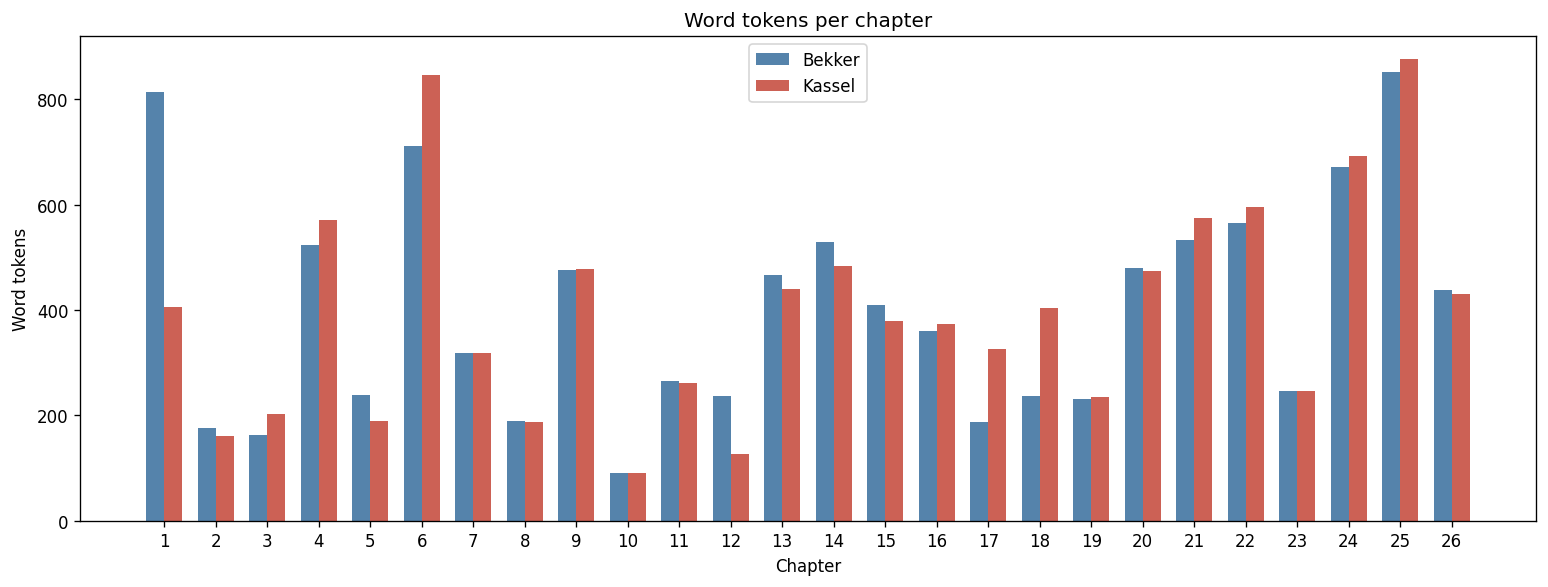

,Bekker,Kassel,Diff (K−B)
Chapter,,,
1,814,406,-408
2,175,160,-15
3,163,203,40
4,523,570,47
5,238,189,-49
6,711,845,134
7,318,319,1
8,189,188,-1
9,475,477,2


In [9]:
def chapter_token_counts(sents):
    counts = Counter()
    for s in sents:
        for t in s['tokens']:
            if t[3] != 'PUNCT':
                ch = get_chapter(t[9])
                if ch:
                    counts[ch] += 1
    return counts

bk_ch = chapter_token_counts(bekker_sents)
ks_ch = chapter_token_counts(kassel_sents)
chapters = sorted(set(bk_ch) | set(ks_ch))

fig, ax = plt.subplots(figsize=(13, 5))
w = 0.35
x = range(len(chapters))
ax.bar([i - w/2 for i in x], [bk_ch.get(c, 0) for c in chapters], w,
       label='Bekker', color='#2a6496', alpha=0.8)
ax.bar([i + w/2 for i in x], [ks_ch.get(c, 0) for c in chapters], w,
       label='Kassel', color='#c0392b', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(chapters)
ax.set_xlabel('Chapter')
ax.set_ylabel('Word tokens')
ax.set_title('Word tokens per chapter')
ax.legend()
plt.tight_layout()
plt.show()

ch_df = pd.DataFrame({
    'Bekker':  [bk_ch.get(c, 0) for c in chapters],
    'Kassel':  [ks_ch.get(c, 0) for c in chapters],
}, index=chapters)
ch_df['Diff (K−B)'] = ch_df['Kassel'] - ch_df['Bekker']
ch_df.index.name = 'Chapter'
ch_df

---
## 2. Textual Variants: How and How Often Do the Readings Differ?

We align the two treebanks **chapter by chapter** using `difflib.SequenceMatcher` on the word-form sequences (excluding punctuation). This lets us identify and classify every point of divergence between the two editions.

### 2.1 Build aligned chapter sequences

In [10]:
def build_chapter_tokens(sents):
    """Return {chapter_int: [(form, lemma, upos, deprel, ref), ...]} for non-punct tokens."""
    ch_map = defaultdict(list)
    for s in sents:
        for t in s['tokens']:
            if t[3] == 'PUNCT':
                continue
            ch = get_chapter(t[9])
            ref = get_ref(t[9])
            if ch:
                ch_map[ch].append({
                    'form': t[1], 'lemma': t[2], 'upos': t[3],
                    'feats': t[5], 'deprel': t[7], 'ref': ref,
                })
    return dict(ch_map)

bk_chapters = build_chapter_tokens(bekker_sents)
ks_chapters = build_chapter_tokens(kassel_sents)

all_chapters = sorted(set(bk_chapters) | set(ks_chapters))
print(f'{len(all_chapters)} chapters to align')

26 chapters to align


### 2.2 Detect and classify all variants

In [11]:
def classify_variant(bk_forms, ks_forms):
    """Classify a single change region.
    Returns one of:
      'accent_only'     — same base letters, different diacritics
      'substitution'    — same number of tokens, different word(s)
      'insertion_K'     — Kassel has extra tokens not in Bekker
      'insertion_B'     — Bekker has extra tokens not in Kassel
      'reorder'         — same multiset of forms, different order
      'complex'         — different token counts AND different words
    """
    bk_stripped = [strip_accents(f) for f in bk_forms]
    ks_stripped = [strip_accents(f) for f in ks_forms]

    if bk_stripped == ks_stripped:
        return 'accent_only'
    if len(bk_forms) == 0:
        return 'insertion_K'
    if len(ks_forms) == 0:
        return 'insertion_B'
    if len(bk_forms) == len(ks_forms):
        if sorted(bk_stripped) == sorted(ks_stripped):
            return 'reorder'
        return 'substitution'
    if sorted(bk_stripped) == sorted(ks_stripped):
        return 'reorder'
    return 'complex'


variants = []  # list of dicts with variant info

for ch in all_chapters:
    bk_toks = bk_chapters.get(ch, [])
    ks_toks = ks_chapters.get(ch, [])
    bk_forms = [t['form'] for t in bk_toks]
    ks_forms = [t['form'] for t in ks_toks]

    sm = SequenceMatcher(None, bk_forms, ks_forms, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            continue
        bk_span = bk_forms[i1:i2]
        ks_span = ks_forms[j1:j2]
        vtype = classify_variant(bk_span, ks_span)

        # Reference location (from the Bekker side if available, else Kassel)
        ref = (bk_toks[i1]['ref'] if i1 < len(bk_toks)
               else ks_toks[j1]['ref'] if j1 < len(ks_toks) else '?')

        variants.append({
            'chapter': ch,
            'ref': ref,
            'type': vtype,
            'bekker_forms': ' '.join(bk_span) if bk_span else '∅',
            'kassel_forms': ' '.join(ks_span) if ks_span else '∅',
            'bk_len': len(bk_span),
            'ks_len': len(ks_span),
        })

var_df = pd.DataFrame(variants)
print(f'Total variant regions detected: {len(var_df)}')
print()
print('Variant types:')
print(var_df['type'].value_counts().to_string())

Total variant regions detected: 652

Variant types:
substitution    357
accent_only      97
insertion_K      73
complex          70
insertion_B      55


### 2.3 Variant frequency overview

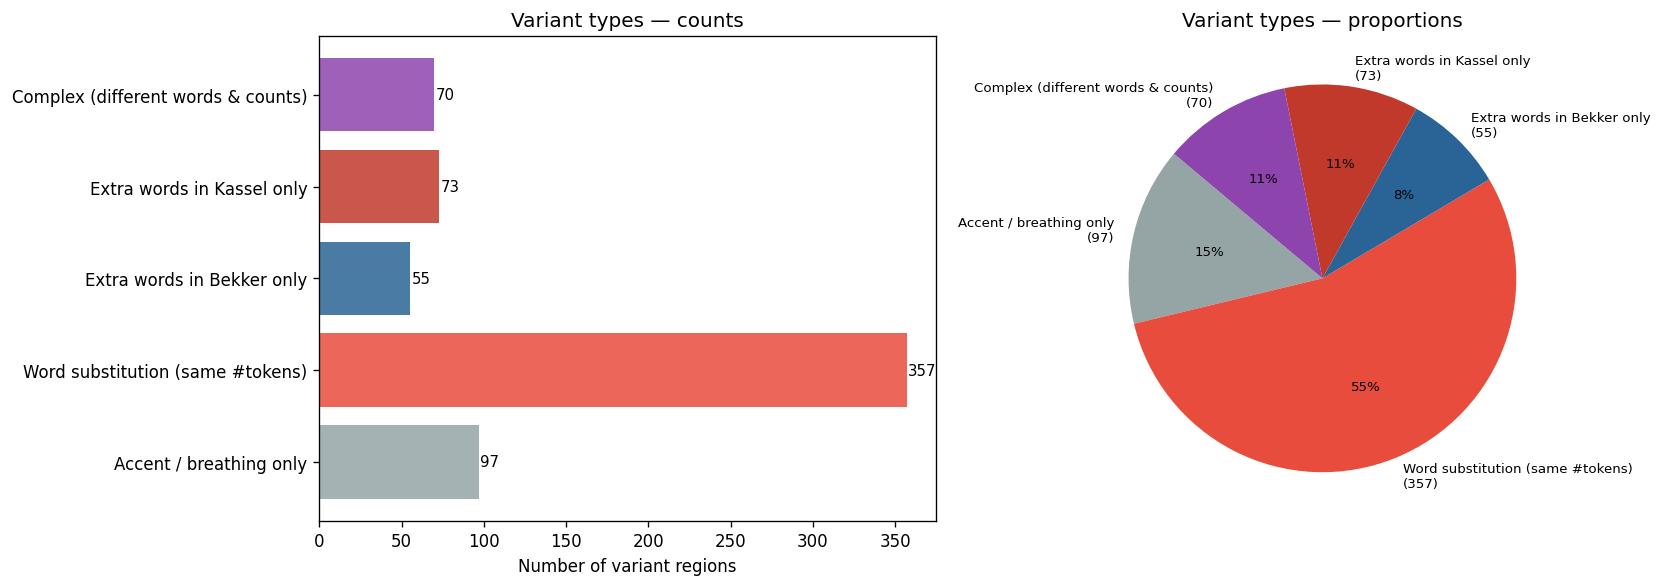

In [12]:
type_order = ['accent_only', 'substitution', 'reorder',
              'insertion_B', 'insertion_K', 'complex']
type_labels = {
    'accent_only':  'Accent / breathing only',
    'substitution': 'Word substitution (same #tokens)',
    'reorder':      'Word reordering',
    'insertion_B':  'Extra words in Bekker only',
    'insertion_K':  'Extra words in Kassel only',
    'complex':      'Complex (different words & counts)',
}
type_colors = {
    'accent_only':  '#95a5a6',
    'substitution': '#e74c3c',
    'reorder':      '#f39c12',
    'insertion_B':  '#2a6496',
    'insertion_K':  '#c0392b',
    'complex':      '#8e44ad',
}

counts = var_df['type'].value_counts()
ordered = [t for t in type_order if t in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
vals = [counts[t] for t in ordered]
colors = [type_colors[t] for t in ordered]
labels = [type_labels[t] for t in ordered]
axes[0].barh(labels, vals, color=colors, alpha=0.85)
axes[0].set_xlabel('Number of variant regions')
axes[0].set_title('Variant types — counts')
for i, v in enumerate(vals):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# Pie chart
axes[1].pie(vals, labels=[f'{l}\n({v})' for l, v in zip(labels, vals)],
            colors=colors, autopct='%1.0f%%', startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('Variant types — proportions')

plt.tight_layout()
plt.show()

### 2.4 Variants per chapter

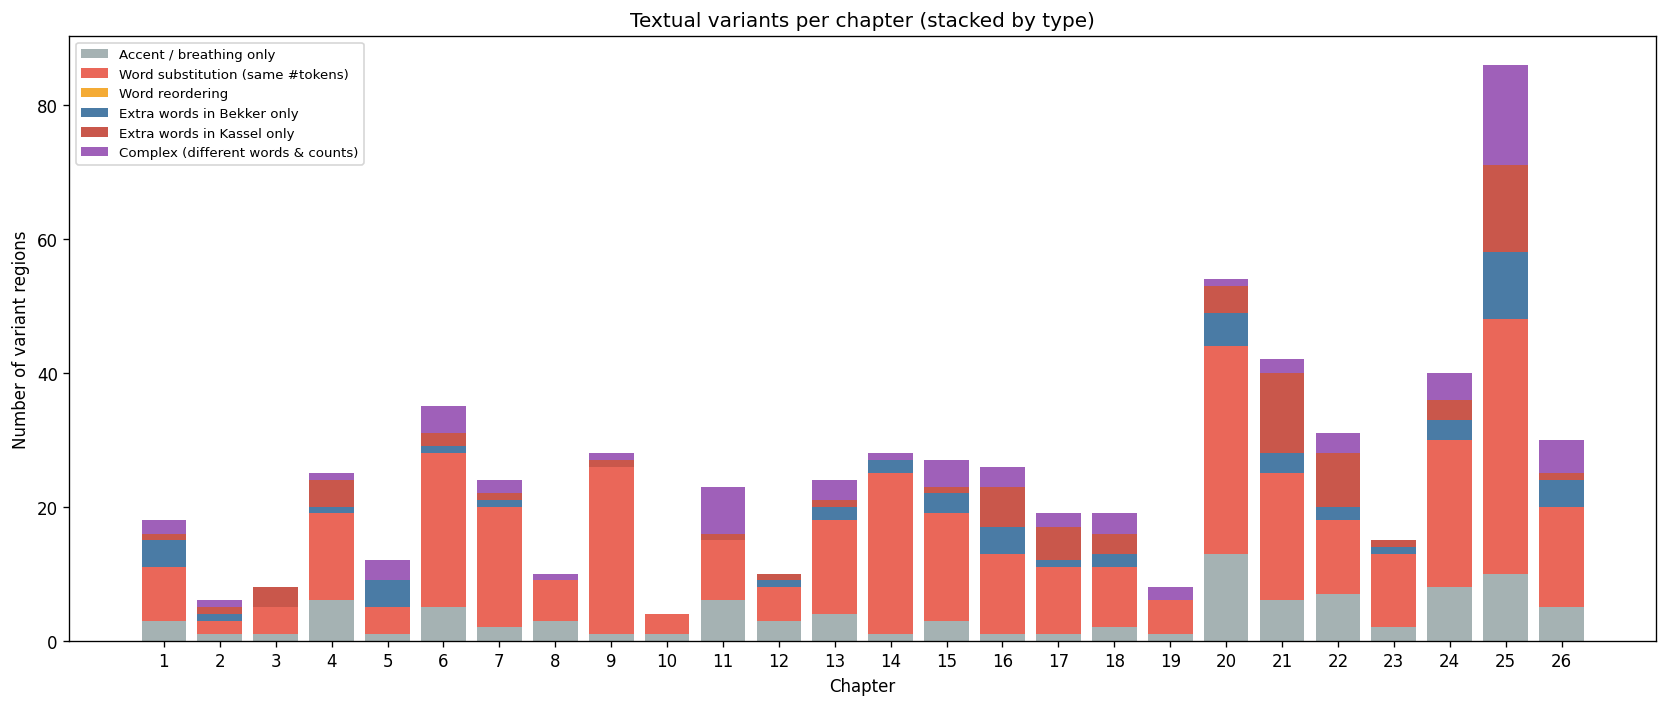

In [13]:
# Group by chapter and type
ch_type = var_df.groupby(['chapter', 'type']).size().unstack(fill_value=0)
# Ensure all types present
for t in type_order:
    if t not in ch_type.columns:
        ch_type[t] = 0
ch_type = ch_type[type_order].reindex(all_chapters, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = [0] * len(all_chapters)
for t in type_order:
    vals = ch_type[t].values
    ax.bar(all_chapters, vals, bottom=bottom, label=type_labels[t],
           color=type_colors[t], alpha=0.85)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xlabel('Chapter')
ax.set_ylabel('Number of variant regions')
ax.set_title('Textual variants per chapter (stacked by type)')
ax.set_xticks(all_chapters)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 2.5 Substantive textual variants (excluding accent-only)

Accent and breathing differences are largely orthographic (e.g., grave vs. acute on oxytones). Let's focus on the **substantive** variants — places where the editions actually read different words.

In [14]:
subst_df = var_df[var_df['type'] != 'accent_only'].copy()
print(f'Substantive variants (non-accent): {len(subst_df)}')
print(f'Accent-only variants:              {len(var_df) - len(subst_df)}')
print()

# Count total tokens affected
bk_tokens_affected = subst_df['bk_len'].sum()
ks_tokens_affected = subst_df['ks_len'].sum()
bk_total = sum(len(bk_chapters.get(c, [])) for c in all_chapters)
ks_total = sum(len(ks_chapters.get(c, [])) for c in all_chapters)

print(f'Bekker tokens in variant regions:  {bk_tokens_affected} / {bk_total} '
      f'({100*bk_tokens_affected/bk_total:.1f}%)')
print(f'Kassel tokens in variant regions:  {ks_tokens_affected} / {ks_total} '
      f'({100*ks_tokens_affected/ks_total:.1f}%)')

Substantive variants (non-accent): 555
Accent-only variants:              97

Bekker tokens in variant regions:  1300 / 10401 (12.5%)
Kassel tokens in variant regions:  1263 / 10364 (12.2%)


### 2.6 Sample substantive variants

Here are concrete examples of the most interesting textual differences.

In [20]:
# Show substitutions first — these are the clearest "different readings"
print('═' * 80)
print('WORD SUBSTITUTIONS (same number of tokens, different words)')
print('═' * 80)
subs = subst_df[subst_df['type'] == 'substitution'].head(25)
for _, row in subs.iterrows():
    print(f"  Ch. {row['chapter']:>2}, {row['ref']:<12}  "
          f"Bekker: {row['bekker_forms']:<30}  Kassel: {row['kassel_forms']}")

print()
print('═' * 80)
print('INSERTIONS / OMISSIONS')
print('═' * 80)
inserts = subst_df[subst_df['type'].isin(['insertion_B', 'insertion_K'])].head(20)
for _, row in inserts.iterrows():
    direction = 'Bekker+' if row['type'] == 'insertion_B' else 'Kassel+'
    extra = row['bekker_forms'] if row['type'] == 'insertion_B' else row['kassel_forms']
    print(f"  Ch. {row['chapter']:>2}, {row['ref']:<12}  "
          f"{direction}: {extra}")

print()
print('═' * 80)
print('COMPLEX VARIANTS (different words and different counts)')
print('═' * 80)
cpx = subst_df[subst_df['type'] == 'complex'].head(15)
for _, row in cpx.iterrows():
    print(f"  Ch. {row['chapter']:>2}, {row['ref']}")
    print(f"      Bekker: {row['bekker_forms']}")
    print(f"      Kassel: {row['kassel_forms']}")
    print()

════════════════════════════════════════════════════════════════════════════════
WORD SUBSTITUTIONS (same number of tokens, different words)
════════════════════════════════════════════════════════════════════════════════
  Ch.  1, 1.3           Bekker: γένει                           Kassel: ἐν
  Ch.  1, 1.4           Bekker: κ-                              Kassel: καὶ
  Ch.  1, 1.4           Bekker: δ᾿                              Kassel: δ’
  Ch.  1, 1.6           Bekker: οἱ                              Kassel: ἡ
  Ch.  1, 1.7           Bekker: μετ᾿                            Kassel: μετ’
  Ch.  1, 1.7           Bekker: εἴθ᾿                            Kassel: εἴθ’
  Ch.  1, 1.11          Bekker: μουσικόν                        Kassel: φυσικόν
  Ch.  1, 1.13          Bekker: οἳ                              Kassel: αἳ
  Ch.  2, 2.1           Bekker: καθ᾿                            Kassel: καθ’
  Ch.  2, 2.4           Bekker: Δηλιάδα                         Kassel: Δειλιάδα
  Ch.  3, 3

### 2.7 Do the textual variants affect the dependency annotation?

When forms differ, the lemma, POS tag, or dependency relation may also change. Let's measure how often textual variants produce annotation differences.

In [16]:
# For substitution variants (same token count), check if annotations also differ
annot_diffs = {'lemma': 0, 'upos': 0, 'feats': 0, 'deprel': 0, 'total': 0}

for ch in all_chapters:
    bk_toks = bk_chapters.get(ch, [])
    ks_toks = ks_chapters.get(ch, [])
    bk_forms = [t['form'] for t in bk_toks]
    ks_forms = [t['form'] for t in ks_toks]

    sm = SequenceMatcher(None, bk_forms, ks_forms, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'replace' and (i2 - i1) == (j2 - j1):
            # Same number of tokens — can compare pairwise
            for bi, ki in zip(range(i1, i2), range(j1, j2)):
                bt, kt = bk_toks[bi], ks_toks[ki]
                if strip_accents(bt['form']) == strip_accents(kt['form']):
                    continue  # accent-only, skip
                annot_diffs['total'] += 1
                if bt['lemma'] != kt['lemma']:
                    annot_diffs['lemma'] += 1
                if bt['upos'] != kt['upos']:
                    annot_diffs['upos'] += 1
                if bt['feats'] != kt['feats']:
                    annot_diffs['feats'] += 1
                if bt['deprel'] != kt['deprel']:
                    annot_diffs['deprel'] += 1

print(f"Among {annot_diffs['total']} word-level substitutions:")
for key in ['lemma', 'upos', 'feats', 'deprel']:
    pct = 100 * annot_diffs[key] / annot_diffs['total'] if annot_diffs['total'] else 0
    print(f"  {key:<8} differs in {annot_diffs[key]:>4} cases ({pct:.1f}%)")

Among 392 word-level substitutions:
  lemma    differs in   68 cases (17.3%)
  upos     differs in  104 cases (26.5%)
  feats    differs in  123 cases (31.4%)
  deprel   differs in  160 cases (40.8%)


In [21]:
# Show examples where the variant changes the POS or deprel
print('Examples where a textual variant changes the UPOS or DEPREL:')
print('─' * 90)
shown = 0
for ch in all_chapters:
    bk_toks = bk_chapters.get(ch, [])
    ks_toks = ks_chapters.get(ch, [])
    bk_forms = [t['form'] for t in bk_toks]
    ks_forms = [t['form'] for t in ks_toks]

    sm = SequenceMatcher(None, bk_forms, ks_forms, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'replace' and (i2 - i1) == (j2 - j1):
            for bi, ki in zip(range(i1, i2), range(j1, j2)):
                bt, kt = bk_toks[bi], ks_toks[ki]
                if (strip_accents(bt['form']) != strip_accents(kt['form'])
                    and (bt['upos'] != kt['upos'] or bt['deprel'] != kt['deprel'])):
                    print(f"  Ch {ch}, {bt['ref']}")
                    print(f"    Bekker: {bt['form']:<20} {bt['upos']:<6} {bt['deprel']:<15} lemma={bt['lemma']}")
                    print(f"    Kassel: {kt['form']:<20} {kt['upos']:<6} {kt['deprel']:<15} lemma={kt['lemma']}")
                    print()
                    shown += 1
                    if shown >= 20:
                        break
            if shown >= 20:
                break
    if shown >= 20:
        break
print(f'(showing first {shown} examples)')

Examples where a textual variant changes the UPOS or DEPREL:
──────────────────────────────────────────────────────────────────────────────────────────
  Ch 1, 1.3
    Bekker: γένει                NOUN   obl             lemma=γένος
    Kassel: ἐν                   ADP    case            lemma=ἐν

  Ch 1, 1.4
    Bekker: κ-                   CCONJ  cc              lemma=καί
    Kassel: καὶ                  ADV    advmod          lemma=καί

  Ch 1, 1.6
    Bekker: οἱ                   DET    nsubj           lemma=ὁ
    Kassel: ἡ                    DET    det             lemma=ὁ

  Ch 1, 1.7
    Bekker: εἴθ᾿                 SCONJ  mark            lemma=εἴτε
    Kassel: εἴθ’                 CCONJ  cc              lemma=εἴτε

  Ch 2, 2.4
    Bekker: Δηλιάδα              PROPN  orphan          lemma=Δηλιάς
    Kassel: Δειλιάδα             PROPN  appos           lemma=Δειλιάς

  Ch 4, 4.5
    Bekker: διὰ                  ADP    case            lemma=διά
    Kassel: ᾗ                    ADV   

### 2.8 Annotation-only differences (same text, different annotation)

Even where both editions read the *same* word, the treebanks may annotate it differently (different head, deprel, UPOS, etc.). Let's measure this in the `equal` spans.

In [22]:
# In 'equal' spans (identical forms), how often do annotations differ?
annot_same_text = {'total': 0, 'lemma': 0, 'upos': 0, 'feats': 0, 'deprel': 0}

for ch in all_chapters:
    bk_toks = bk_chapters.get(ch, [])
    ks_toks = ks_chapters.get(ch, [])
    bk_forms = [t['form'] for t in bk_toks]
    ks_forms = [t['form'] for t in ks_toks]

    sm = SequenceMatcher(None, bk_forms, ks_forms, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            for bi, ki in zip(range(i1, i2), range(j1, j2)):
                bt, kt = bk_toks[bi], ks_toks[ki]
                annot_same_text['total'] += 1
                if bt['lemma'] != kt['lemma']:
                    annot_same_text['lemma'] += 1
                if bt['upos'] != kt['upos']:
                    annot_same_text['upos'] += 1
                if bt['feats'] != kt['feats']:
                    annot_same_text['feats'] += 1
                if bt['deprel'] != kt['deprel']:
                    annot_same_text['deprel'] += 1

print(f"Among {annot_same_text['total']} tokens with IDENTICAL forms in both editions:")
for key in ['lemma', 'upos', 'feats', 'deprel']:
    pct = 100 * annot_same_text[key] / annot_same_text['total'] if annot_same_text['total'] else 0
    print(f"  {key:<8} differs in {annot_same_text[key]:>4} cases ({pct:.1f}%)")

print()
print('This separates annotation divergence from textual divergence: even on shared text,')
print('the two treebanks may parse the sentence structure differently.')

Among 8997 tokens with IDENTICAL forms in both editions:
  lemma    differs in  497 cases (5.5%)
  upos     differs in  744 cases (8.3%)
  feats    differs in 2884 cases (32.1%)
  deprel   differs in 2151 cases (23.9%)

This separates annotation divergence from textual divergence: even on shared text,
the two treebanks may parse the sentence structure differently.


### 2.9 Full variant table

Export all substantive variants for scholarly reference.

In [24]:
display_df = subst_df[['chapter', 'ref', 'type', 'bekker_forms', 'kassel_forms']].copy()
display_df.columns = ['Chapter', 'Reference', 'Variant type', 'Bekker reading', 'Kassel reading']
display_df = display_df.reset_index(drop=True)
display_df.index += 1
display_df.index.name = '#'

print(f'Total substantive variants: {len(display_df)}')
display_df[1:100]

Total substantive variants: 555


,Chapter,Reference,Variant type,Bekker reading,Kassel reading
#,,,,,
2,1,1.4,substitution,κ-,καὶ
3,1,1.4,substitution,δ᾿,δ’
4,1,1.6,substitution,οἱ,ἡ
5,1,1.7,insertion_B,ἐποποιία,∅
6,1,1.7,complex,ἢ,καὶ ἡ
...,...,...,...,...,...
96,7,7.5,complex,μετ᾿,μὲν μετ’
97,7,7.6,substitution,μετ᾿,μετ’
98,7,7.6,substitution,μετ᾿,μετ’


### 2.10 Summary

#### How do the editions differ?
- **Sentence segmentation** diverges significantly: Bekker's text is split into far more sentences (reflecting different editorial punctuation).
- **Token counts** are close but not identical — Kassel's critical edition sometimes omits or adds words relative to Bekker's 1831 text.
- **POS and dependency distributions** are broadly similar, as expected for the same underlying work.

#### How often do the readings differ?
- Every chapter contains textual variants between the two editions.
- Variants fall into several categories: accent/breathing differences (orthographic), direct word substitutions, word-order changes, insertions/omissions, and complex multi-word divergences.
- A substantial fraction of variants also trigger changes in the linguistic annotation (different lemma, POS, or dependency relation), making these more than superficial text differences — they affect the syntactic parse.
- Even where the text is identical, the two treebanks occasionally analyze the syntax differently, reflecting the independent annotation process.